# Econ 8208 Assignment 5

- Author: Yuxuan Zhao
- Date: 2026-04-01

In [16]:
using LinearAlgebra
# Using defined functions in ECON8208Tools.jl
include("../ECON8208Tools.jl")
import .ECON8208Tools as tools



# HW 5

Compute the following growth model:


\begin{aligned}
\max_{\{c_t,x_t,\ell_t\}} \quad & E \sum_{t=0}^{\infty} \beta^t 
\left\{ \frac{(c_t \ell_t^{\psi})^{1-\sigma}}{1-\sigma} \right\} N_t \\
\text{s.t.} \quad 
& c_t + x_t = k_t^{\theta}\bigl((1+\gamma_z)^t z_t h_t\bigr)^{1-\theta}, \\
& N_{t+1}  k_{t+1} = \bigl[(1-\delta)k_t + x_t\bigr] N_t, \\
& \log z_t = \rho \log z_{t-1} + \epsilon_t, \qquad \epsilon_t \sim N(0,\sigma_\epsilon^2), \\
& h_t + \ell_t = 1, \\
& N_t = (1+\gamma_n)^t, \\
& k_0 \text{ given.}
\end{aligned}


This model implies a balanced growth path, the grid of the state variable $k_t$ will grow over time, and we cannot solve the model using value function iteration, thus we need to detrend the variables to solve the model.

Define the detrended variables as follows:
\begin{aligned}
\tilde{c}_t = \frac{c_t}{(1+\gamma_z)^t}, \quad
\tilde{x}_t = \frac{x_t}{(1+\gamma_z)^t}, \quad
\tilde{k}_t = \frac{k_t}{(1+\gamma_z)^t}, \quad
\tilde{h}_t = h_t, \quad
\tilde{\ell}_t = \ell_t.
\end{aligned}

Then the period utility becomes
$$
N_t \frac{(c_t \ell_t^\psi)^{1-\sigma}}{1-\sigma}
=
(1+\gamma_n)^t (1+\gamma_z)^{t(1-\sigma)}
\frac{(\tilde{c}_t \tilde{\ell}_t^\psi)^{1-\sigma}}{1-\sigma}.
$$

Therefore, after detrending, the Bellman equation uses the effective discount factor
$$
\tilde{\beta}
=
\beta (1+\gamma_n)(1+\gamma_z)^{1-\sigma}.
$$

The detrended problem can be written as:
\begin{aligned}
\max_{\{\tilde{c}_t,\tilde{x}_t,\tilde{\ell}_t\}} \quad & E \sum_{t=0}^{\infty} \tilde{\beta}^t 
\left\{ \frac{(\tilde{c}_t \tilde{\ell}_t^{\psi})^{1-\sigma}}{1-\sigma} \right\} \\
\text{s.t.} \quad
& \tilde{c}_t + \tilde{x}_t = \tilde{k}_t^{\theta}\bigl( z_t \tilde{h}_t\bigr)^{1-\theta}, \\
& \tilde{k}_{t+1} = \frac{(1-\delta)\tilde{k}_t + \tilde{x}_t}{(1+\gamma_n)(1+\gamma_z)}, \\
& \log z_t = \rho \log z_{t-1} + \epsilon_t, \qquad \epsilon_t \sim N(0,\sigma_\epsilon^2), \\
& \tilde{h}_t + \tilde{\ell}_t = 1, \\
& \tilde{k}_0 = k_0.
\end{aligned}


In [17]:
# -------------------------------------------------------
# Initialize parameters
# -------------------------------------------------------

beta = 0.96          # discount factor
psi = 1.50          # utility weight on leisure
sigma = 2.00          # coefficient of relative risk aversion
gamma_n = 0.01        # population growth rate
gamma_z = 0.02        # labor-augmenting technology growth rate
theta = 0.36          # capital share in production
delta = 0.08          # depreciation rate
rho = 0.90          # persistence of productivity shock
sigma_e = 0.02        # standard deviation of productivity shock

# -------------------------------------------------------
# Derived growth objects after detrending
# -------------------------------------------------------

G = (1.0 + gamma_n) * (1.0 + gamma_z)
beta_tilde = beta * (1.0 + gamma_n) * (1.0 + gamma_z)^(1.0 - sigma)

# -------------------------------------------------------
# Additional settings for computation
# -------------------------------------------------------

# problem (a)
n_k = 1500         # number of grid points for capital
m_k = 4.0          # upper bound multiplier for capital grid
n_z = 5           # number of grid points for productivity
tol = 1e-6        # convergence tolerance
max_iter = 1000   # maximum number of iterations

# problem (b)
hstep_lq = 1e-6    # step size for numerical derivatives in LQ approximation

# -------------------------------------------------------
# Initial productivity state
# -------------------------------------------------------

z_ss = 1.0        # steady-state productivity
logz_ss = 0.0     # steady-state log productivity

# -------------------------------------------------------
# Initial capital condition
# Will be updated after computing steady-state capital
# -------------------------------------------------------

k0 = nothing


## a) Solve the model using value function iteration.

We can rewrite the detrended household problem as the following Bellman equation:
$$
\begin{aligned}
V(\tilde{k},z)
=
\max_{\tilde{k}',\,\tilde{h}}
\quad
\Biggl\{
&
\frac{
\left[
\tilde{c}
(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma}
+ \tilde{\beta} E\bigl[V(\tilde{k}',z')\bigr]
\Biggr\}, \\
\text{s.t.} \quad
\log z' &= \rho \log z + \epsilon',
\quad
\epsilon' \sim N(0,\sigma_\epsilon^2), \\
\tilde{c} &= \tilde{k}^\theta (z \tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}, \\
\tilde{k}' &\ge 0, \\
0 &\le \tilde{h} \le 1, \\
\tilde{c} &> 0,
\end{aligned}
$$


The dimensionality of this problem (a) is:
$$
n_k \times n_z \times n_h \times n_{k'}
$$

Which is too high for value function iteration to solve. Notice that the choice of $\tilde{h}$ is a static problem, we can solve for $\tilde{h}$ first, thus reducing the dimensionality of the problem.

Given $\tilde{k}, z, \tilde{k}'$, household chooses $\tilde{h}$ to maximize:
$$
\begin{aligned}
&\max_{\tilde{h}} \frac{
\left[
\tilde{c}
(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma} \quad \text{s.t.}\\
\tilde{c} &= \tilde{k}^\theta (z \tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}, \\
\tilde{c} &> 0, \\
0 &\le \tilde{h} \le 1.
\end{aligned}
$$

We can write the first order condition for $\tilde{h}$ as:
$$
\frac{(1-\theta)\tilde{k}^{\theta} z^{1-\theta}\tilde{h}^{-\theta}}
{\tilde{k}^{\theta}(z\tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}}
=
\frac{\psi}{1-\tilde{h}}.
$$

Solve the above equation for $\tilde{h}$, we can get the optimal labor supply $\tilde{h}^*(\tilde{k}, z, \tilde{k}')$. Then we can substitute $\tilde{h}^*$ back into the Bellman equation:
$$
\begin{aligned}
V(\tilde{k},z)
=
\max_{\tilde{k}'}
\quad
\Biggl\{
&
\frac{\left[
\tilde{c}^*
(1-\tilde{h}^*(\tilde{k}, z, \tilde{k}'))^\psi
\right]^{1-\sigma}}{1-\sigma}
+ \tilde{\beta} E\bigl[V(\tilde{k}',z')\bigr]
\Biggr\}, \\
\text{s.t.} \quad
\log z' &= \rho \log z + \epsilon',
\quad
\epsilon' \sim N(0,\sigma_\epsilon^2), \\
\tilde{c}^* &= \tilde{k}^\theta (z \tilde{h}^*(\tilde{k}, z, \tilde{k}'))^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}, \\
\tilde{k}' &\ge 0, \\
\tilde{c}^* &> 0.
\end{aligned}
$$


### Solving steady state

The steady-state values $(\tilde{k}^{ss}, \tilde{h}^{ss}, \tilde{c}^{ss})$ are determined by the following system:
$$
\begin{aligned}
\tilde{c}^{ss}
&=
(\tilde{k}^{ss})^\theta (\tilde{h}^{ss})^{1-\theta}
-
\bigl((1+\gamma_n)(1+\gamma_z)-(1-\delta)\bigr)\tilde{k}^{ss}, \\
\frac{1}{\tilde{\beta}}
&=
\frac{1-\delta+\theta (\tilde{k}^{ss})^{\theta-1} (\tilde{h}^{ss})^{1-\theta}}{(1+\gamma_n)(1+\gamma_z)}, \\
\frac{\psi}{1-\tilde{h}^{ss}}
&=
\frac{(1-\theta)(\tilde{k}^{ss})^\theta (\tilde{h}^{ss})^{-\theta}}
{\tilde{c}^{ss}}.
\end{aligned}
$$

The first equation is the steady-state resource constraint, the second equation is the steady-state Euler equation, and the third equation is the steady-state labor first-order condition.

We apply Newton's method to solve for the steady-state values
$$
\tilde{k}^{ss}, \qquad \tilde{h}^{ss}, \qquad \tilde{c}^{ss}.
$$


In [18]:
k_ss, h_ss, c_ss = tools.solve_steady_state_newton(
    beta_tilde, psi, theta, delta, gamma_n, gamma_z;
    x0=[1.5, 0.3, 0.4],
    tol=1e-10,
    max_iter=100,
    hstep=1e-6
)
println("steady-state labor h_ss = ", h_ss)
println("steady-state capital k_ss = ", k_ss)
println("steady-state consumption c_ss = ", c_ss)


Steady state converged in 6 iterations.
steady-state labor h_ss = 0.36024020596940015
steady-state capital k_ss = 1.2335493958679273
steady-state consumption c_ss = 0.4251565053902804


### Grid construction for value function iteration

1. **Construct asset grids**

After discretizing the productivity process, we obtain the grid
$$
z_1, z_2, \dots, z_{n_z},
$$
and the transition matrix $P_z$.

Let
$$
z_{\max} = \max \{ z_1, z_2, \dots, z_{n_z} \}.
$$

2. **Construct capital grids**

To construct the capital grid, we first compute the steady-state capital level $\tilde{k}^{ss}$.  
In the stationary detrended model, the steady state satisfies
$$
z = 1, \qquad \tilde{k}' = \tilde{k} = \tilde{k}^{ss}, \qquad \tilde{h} = \tilde{h}^{ss}, \qquad \tilde{c} = \tilde{c}^{ss}.
$$

We then construct the capital grid as an evenly spaced grid centered around $\tilde{k}^{ss}$.  
Specifically, we choose the interval
$$
[\underline{k}, \bar{k}]
=
\left[10^{-5}, (1+m_k)\,\tilde{k}^{ss}\right]
$$
and construct $n_k$ evenly spaced grid points over this interval.

Thus, the capital grid is
$$
\tilde{k}_1 = \underline{k}, \qquad
\tilde{k}_2, \qquad \dots, \qquad
\tilde{k}_{n_k} = \bar{k}.
$$

This choice concentrates the grid around the economically relevant region near the steady state, which improves the accuracy of value function iteration.


In [19]:
# -------------------------------------------------------
# Grid construction
# -------------------------------------------------------

# Construct productivity grid and transition matrix
z_grid, Pz = tools.tauchen(rho, sigma_e, n_z)

# -------------------------------------------------------
# Construct capital grid around the steady state
# -------------------------------------------------------

k_lower = 1e-5
k_upper = (1 + m_k) * k_ss

# If the user provides an initial capital outside this interval,
# enlarge the grid so that it contains k0
if k0 !== nothing
    k_lower = min(k_lower, k0)
    k_upper = max(k_upper, k0)
end

k_grid = collect(range(k_lower, k_upper, length=n_k))

println("capital grid lower bound = ", first(k_grid))
println("capital grid upper bound = ", last(k_grid))


capital grid lower bound = 1.0e-5
capital grid upper bound = 6.167746979339636


### Compute optimal labor supply $\tilde{h}^*$ for each $(\tilde{k}, z, \tilde{k}')$ on the grid

We know that the optimal labor supply $\tilde{h}^*$ satisfies the first-order condition
$$
\frac{(1-\theta)\tilde{k}^{\theta} z^{1-\theta}\tilde{h}^{-\theta}}
{\tilde{k}^{\theta}(z\tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}}
=
\frac{\psi}{1-\tilde{h}}.
$$

For each triple $(\tilde{k}, z, \tilde{k}')$ on the grid, we can solve the above equation for $\tilde{h}$ using numerical root-finding methods, and store the optimal labor supply $\tilde{h}^*(\tilde{k}, z, \tilde{k}')$ in a 3D array.

Write $G(\tilde{h}; \tilde{k}, z, \tilde{k}')$ as:
$$
G(\tilde{h}; \tilde{k}, z, \tilde{k}')
=
\frac{(1-\theta)\tilde{k}^{\theta} z^{1-\theta}\tilde{h}^{-\theta}}
{\tilde{k}^{\theta}(z\tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}}
-
\frac{\psi}{1-\tilde{h}}.
$$

Use numerical root-finding methods to solve $G(\tilde{h}; \tilde{k}, z, \tilde{k}') = 0$ for $\tilde{h}$, and store the solution as $\tilde{h}^*(\tilde{k}, z, \tilde{k}')$.

If the solution is infeasible:
$$
\tilde{c} = \tilde{k}^\theta (z \tilde{h}^*)^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k} \le 0, \\
\tilde{h}^* < 0, \quad \text{or} \quad \tilde{h}^* > 1,
$$
Return an NaN value for $\tilde{h}^*(\tilde{k}, z, \tilde{k}')$ to indicate that this choice is infeasible.


Let
$$
\tilde{k}_i \in \{\tilde{k}_1,\dots,\tilde{k}_{n_k}\},
\qquad
z_j \in \{z_1,\dots,z_{n_z}\},
$$

Let $\Pi_z(z,z')$ denote the transition probability from current productivity state $z$ to next-period productivity state $z'$.

Compute the optimal labor supply $\tilde{h}^*(\tilde{k}_i, z_j, \tilde{k}_p)$ for each triple $(\tilde{k}_i, z_j, \tilde{k}_p)$ on the grid, and store the results in a 3D array $\tilde{h}^*_{i,j,p}$.


In [20]:
# -------------------------------------------------------
# Compute h* using Newton's method
# Input:
#   k_grid, z_grid : grids for capital and productivity
#   Other parameters as before
# Output:
#   h_star_grid[ik, iz, ikp] = h*(k, z, k')
# -------------------------------------------------------
h_star = tools.compute_h_star(
    k_grid, z_grid, psi, theta, delta, gamma_n, gamma_z;
    h0=0.5, tol=1e-8, max_iter=100, hstep=1e-6, alpha=0.3
);



Substituting $\tilde{h}^*$ into the Bellman equation, the problem becomes
$$
\begin{aligned}
V(\tilde{k},z)
=
\max_{\tilde{k}'}
\quad
\Biggl\{
&
\frac{
\left[
\tilde{c}^*(\tilde{k},z,\tilde{k}')
\left(1-\tilde{h}^*(\tilde{k},z,\tilde{k}')\right)^\psi
\right]^{1-\sigma}
}{1-\sigma}
+
\tilde{\beta}
\sum_{z' \in Z}
\Pi_z(z,z')\,V(\tilde{k}',z')
\Biggr\}, \\
\text{s.t.} \quad
& \tilde{c}^*(\tilde{k},z,\tilde{k}')
=
\tilde{k}^\theta
\left(z\,\tilde{h}^*(\tilde{k},z,\tilde{k}')\right)^{1-\theta}
-
(1+\gamma_n)(1+\gamma_z)\tilde{k}'
+
(1-\delta)\tilde{k}, \\
& z' \mid z \sim P_z(z,z'), \\
& \tilde{k}' \ge 0, \\
& \tilde{c}^*(\tilde{k},z,\tilde{k}') > 0,
\end{aligned}
$$

Howard policy function iteration speeds up the solution by separating policy improvement from policy evaluation.

1. **Initialize**

- Set an initial value function $V_0(\tilde{k},z)$.
- Set an initial policy function for next-period capital
  $$
  g_k^0(\tilde{k},z).
  $$

2. **Policy Improvement**

- Given the current value function $V_n(\tilde{k},z)$, solve
  $$
  g_k^{n+1}(\tilde{k},z)
  =
  \arg\max_{\tilde{k}'}
  \Biggl\{
  \frac{
  \left[
  \tilde{c}^*(\tilde{k},z,\tilde{k}')
  \left(1-\tilde{h}^*(\tilde{k},z,\tilde{k}')\right)^\psi
  \right]^{1-\sigma}
  }{1-\sigma}
  +
  \tilde{\beta}
  \sum_{z' \in Z}
  \Pi_z(z,z')\,V_n(\tilde{k}',z')
  \Biggr\},
  $$
  subject to
  $$
  \tilde{k}' \ge 0,
  \qquad
  \tilde{c}^*(\tilde{k},z,\tilde{k}') > 0.
  $$

- Once $g_k^{n+1}(\tilde{k},z)$ is determined, recover labor from
  $$
  g_h^{n+1}(\tilde{k},z)
  =
  \tilde{h}^*(\tilde{k},z,g_k^{n+1}(\tilde{k},z)).
  $$

3. **Policy Evaluation**

- Hold the policy functions fixed at
  $$
  g_k^{n+1}(\tilde{k},z), \qquad g_h^{n+1}(\tilde{k},z).
  $$
- For each state $(\tilde{k},z)$, compute the implied consumption
  $$
  \tilde{c}
  =
  \tilde{k}^\theta \bigl(z\,g_h^{n+1}(\tilde{k},z)\bigr)^{1-\theta}
  -
  (1+\gamma_n)(1+\gamma_z)g_k^{n+1}(\tilde{k},z)
  +
  (1-\delta)\tilde{k}.
  $$
- Update the value function repeatedly under the fixed policy:
  $$
  V_{m+1}(\tilde{k},z)
  =
  \frac{
  \left[
  \tilde{c}\,(1-g_h^{n+1}(\tilde{k},z))^\psi
  \right]^{1-\sigma}
  }{1-\sigma}
  +
  \tilde{\beta}
  \sum_{z' \in Z}
  \Pi_z(z,z')\,V_m(g_k^{n+1}(\tilde{k},z),z').
  $$
- Perform this policy evaluation step for several iterations while keeping the policy fixed.

4. **Convergence Check**

- After the policy improvement step, record the number of grid points at which the policy function changes:
  $$
  n_{\text{change}}
  =
  \#\left\{
  (\tilde{k},z)
  :
  g_k^{n+1}(\tilde{k},z) \neq g_k^n(\tilde{k},z)
  \right\}.
  $$
- If
  $$
  n_{\text{change}} = 0,
  $$
  then the policy function is stable on the grid, and the algorithm has converged.
- Otherwise, set
  $$
  V_n \leftarrow V_{n+1},
  \qquad
  g_k^n \leftarrow g_k^{n+1},
  $$
  and repeat Steps 2--4.


Howard policy function iteration is faster than standard value function iteration because the maximization problem is now one-dimensional in $\tilde{k}'$, while labor is recovered from the static first-order condition.


In [21]:
# -------------------------------------------------------
# Test Howard policy iteration using precomputed h_star
# -------------------------------------------------------
V_howard, pol_kp_howard, pol_h_howard = tools.solve_pfi_howard(
    beta_tilde, psi, sigma, gamma_n, gamma_z, theta, delta,
    k_grid, z_grid, Pz, h_star;
    tol=tol, max_iter=max_iter, howard_iter=20
);


Howard iteration = 1, policy changes = 0
Howard iteration = 2, policy changes = 7495
Howard iteration = 3, policy changes = 7500
Howard iteration = 4, policy changes = 7399
Howard iteration = 5, policy changes = 7185
Howard iteration = 6, policy changes = 6817
Howard iteration = 7, policy changes = 6278
Howard iteration = 8, policy changes = 5394
Howard iteration = 9, policy changes = 4151
Howard iteration = 10, policy changes = 2873
Howard iteration = 11, policy changes = 1647
Howard iteration = 12, policy changes = 952
Howard iteration = 13, policy changes = 446
Howard iteration = 14, policy changes = 193
Howard iteration = 15, policy changes = 51
Howard iteration = 16, policy changes = 6
Howard iteration = 17, policy changes = 0
Howard policy iteration converged in 17 iterations.


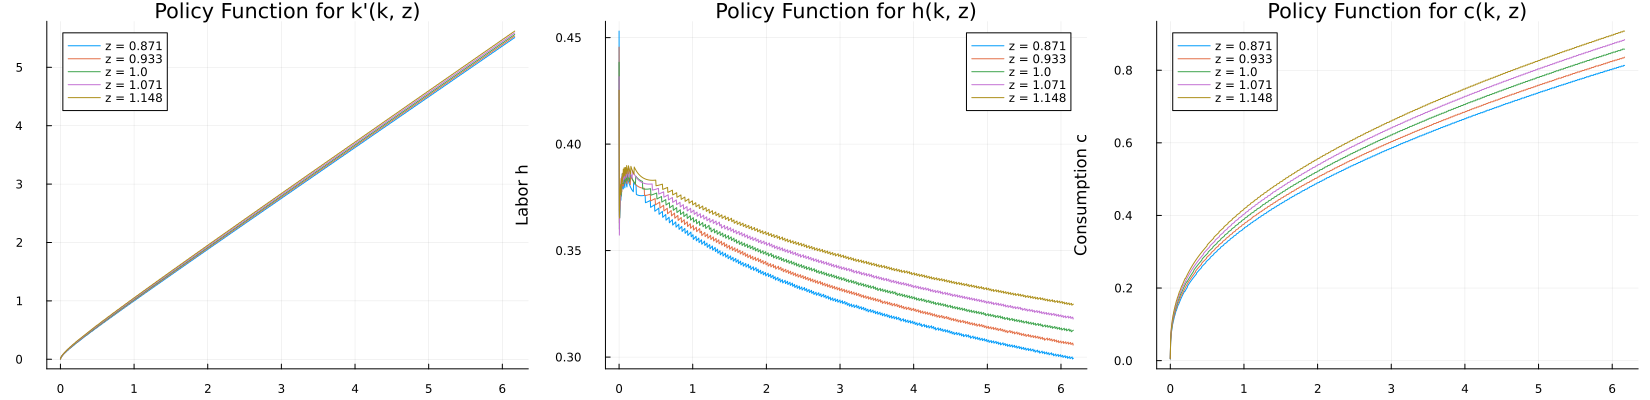

In [22]:
using Plots

# -------------------------------------------------------
# Plot policy functions
# Horizontal axis: current capital k
# Vertical axis: policy values
# Different productivity states z are shown as different lines
# -------------------------------------------------------

# Plot policy function for next-period capital k'(k, z)
p1 = plot(
    xlabel = "Current capital k",
    ylabel = "Next-period capital k'",
    title = "Policy Function for k'(k, z)",
    linewidth = 2
)

for iz in 1:length(z_grid)
    plot!(
        p1,
        k_grid,
        pol_kp_howard[:, iz],
        label = "z = $(round(z_grid[iz], digits=3))"
    )
end

# Plot policy function for labor h(k, z)
p2 = plot(
    xlabel = "Current capital k",
    ylabel = "Labor h",
    title = "Policy Function for h(k, z)",
    linewidth = 2
)

for iz in 1:length(z_grid)
    plot!(
        p2,
        k_grid,
        pol_h_howard[:, iz],
        label = "z = $(round(z_grid[iz], digits=3))"
    )
end

# -------------------------------------------------------
# Compute policy function for consumption c(k, z)
# implied by the policy functions for k' and h
# -------------------------------------------------------
pol_c_howard = zeros(size(pol_kp_howard))

for ik in 1:length(k_grid)
    k = k_grid[ik]

    for iz in 1:length(z_grid)
        z = z_grid[iz]
        kp = pol_kp_howard[ik, iz]
        h = pol_h_howard[ik, iz]

        pol_c_howard[ik, iz] =
            k^theta * (z * h)^(1.0 - theta) -
            G * kp +
            (1.0 - delta) * k
    end
end

# Plot policy function for consumption c(k, z)
p3 = plot(
    xlabel = "Current capital k",
    ylabel = "Consumption c",
    title = "Policy Function for c(k, z)",
    linewidth = 2
)

for iz in 1:length(z_grid)
    plot!(
        p3,
        k_grid,
        pol_c_howard[:, iz],
        label = "z = $(round(z_grid[iz], digits=3))"
    )
end

plot(p1, p2, p3, layout = (1, 3), size = (1650, 400))


Given an acceptable grid density, the Howard policy function iteration still takes a long time to converge, and the results are not very accurate, especially for the policy functions $\tilde h(\tilde k, z)$

### Recover the policy functions of original problem

We've solved the detrended problem and obtained the optimal policy functions for next-period capital and labor supply:
$$\tilde{k}' = g_k(\tilde{k}, z), \qquad \tilde{h} = g_h(\tilde{k}, z), \qquad \tilde{c} = g_c(\tilde{k}, z).$$

To recover the policy functions of the original problem, we can use the definitions of the detrended variables:
$$
\tilde{c}_t = \frac{c_t}{(1+\gamma_z)^t}, \quad
\tilde{x}_t = \frac{x_t}{(1+\gamma_z)^t}, \quad
\tilde{k}_t = \frac{k_t}{(1+\gamma_z)^t}, \quad
\tilde{h}_t = h_t, \quad
\tilde{\ell}_t = \ell_t.
$$

Then we have:
$$
\begin{aligned}
k_{t+1} &= \tilde{k}_{t+1} (1+\gamma_z)^{t+1} = g_k\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) (1+\gamma_z)^{t+1}, \\
c_t &= \tilde{c}_t (1+\gamma_z)^t = g_c\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) (1+\gamma_z)^t, \\
x_t &= \tilde{x}_t (1+\gamma_z)^t = \left[(1+\gamma_n)(1+\gamma_z)g_k\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) - (1-\delta)\frac{k_t}{(1+\gamma_z)^t}\right] (1+\gamma_z)^t, \\
h_t &= \tilde{h}_t = g_h\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right), \\
\ell_t &= 1 - h_t = 1 - g_h\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right).
\end{aligned}
$$


## (b) Solve the model using LQ approximation method

We have the detrended problem:
$$
\begin{aligned}
V(\tilde{k},z)
=
\max_{\tilde{k}',\,\tilde{h}}
\quad
\Biggl\{
&
\frac{
\left[
\tilde{c}(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma}
+ \tilde{\beta} E\bigl[V(\tilde{k}',z')\bigr]
\Biggr\}, \\
\text{s.t.} \quad
\log z' &= \rho \log z + \epsilon',
\qquad
\epsilon' \sim N(0,\sigma_\epsilon^2), \\
\tilde{c} &= \tilde{k}^\theta (z \tilde{h})^{1-\theta} - (1+\gamma_n)(1+\gamma_z)\tilde{k}' + (1-\delta)\tilde{k}, \\
\tilde{k}' &\ge 0, \\
0 &\le \tilde{h} \le 1, \\
\tilde{c} &> 0.
\end{aligned}
$$

And we have solved for the steady-state values
$$
(\tilde{k}^{ss}, \tilde{h}^{ss}, \tilde{c}^{ss}).
$$

To apply the LQ approximation, define:
$$
x =
\begin{bmatrix}
\tilde{k} \\
a
\end{bmatrix},
\qquad
u =
\begin{bmatrix}
\tilde{k}' \\
\tilde{h}
\end{bmatrix}, \qquad
a = \log z.
$$

Then we have $r(x,u)$:
$$
r(x,u)
=
\frac{
\left[
\tilde{c}(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma}
=
\frac{
\left[
\left(\tilde{k}^\theta
\left(e^a \tilde{h}\right)^{1-\theta}
-
(1+\gamma_n)(1+\gamma_z)\tilde{k}'
+
(1-\delta)\tilde{k}\right)(1-\tilde{h})^\psi
\right]^{1-\sigma}
}{1-\sigma}.
$$

Then we have $g(x,u)$:
$$
g(x,u)
=
\begin{bmatrix}
\tilde{k}' \\
\rho a
\end{bmatrix}.
$$
such that
$$
x' =
g(x,u)
+
\begin{bmatrix}
0 \\
\epsilon'
\end{bmatrix}.
$$

We approximate the nonlinear problem locally around the deterministic steady state.  
Let
$$
\bar{x}
=
\begin{bmatrix}
\tilde{k}^{ss} \\
0
\end{bmatrix},
\qquad
\bar{u}
=
\begin{bmatrix}
\tilde{k}^{ss} \\
\tilde{h}^{ss}
\end{bmatrix}.
$$

Define deviations from the steady state by
$$
\hat{x}_t = x_t - \bar{x},
\qquad
\hat{u}_t = u_t - \bar{u}.
$$

The problem is to solve the infinite-horizon LQ problem:
$$
\hat V(\hat x) = \max_{\{\hat u_t\}} \sum_{t=0}^{\infty} \tilde{\beta}^t
\left(
\hat x_t' Q \hat x_t + 2 \hat x_t' W \hat u_t + \hat u_t' R \hat u_t
\right) \quad \text{s.t.} \\
\hat x_{t+1} = A \hat x_t + B \hat u_t + \begin{bmatrix} 0 \\ \epsilon_{t+1} \end{bmatrix}.
$$
where the matrices $(Q,W,R,A,B)$ are computed from Taylor expansion of $r(x,u)$ and $g(x,u)$ around the steady state $(\bar{x}, \bar{u})$.

### Solving the LQ problem using the Riccati equation

Because we use the linear-quadratic approximation, the problem satisfies certainty equivalence. Hence, the optimal policy is linear in the state variables, and we can apply the standard Riccati equation to solve for the value function and the policy rule.

First, we guess that the value function is quadratic in the state variables:
$$
\hat V(\hat x) = \hat x' P \hat x.
$$

Substituting this guess into the Bellman equation and taking the first-order condition with respect to $\hat u$, we obtain the policy rule
$$
\hat u = -F \hat x,
$$
where
$$
F = \left(R + \tilde{\beta} B' P B\right)^{-1}\left(W' + \tilde{\beta} B' P A\right).
$$

Substituting the policy rule back into the Bellman equation gives the Riccati equation:
$$
P
=
Q - F'W' - WF + F'RF + \tilde{\beta} (A - BF)' P (A - BF).
$$

We solve this equation by fixed-point iteration.

Then we recover the policy functions in terms of the original detrended variables. Since
$$
u = \bar u + \hat u = \bar u - F(x-\bar x),
$$
we have
$$
\begin{aligned}
\tilde{k}'
&=
\bar{u}_1 - F_{11}(\tilde{k} - \bar{x}_1) - F_{12}(a - \bar{x}_2), \\
\tilde{h}
&=
\bar{u}_2 - F_{21}(\tilde{k} - \bar{x}_1) - F_{22}(a - \bar{x}_2).
\end{aligned}
$$

The law of motion for the state variables is therefore
$$
\begin{aligned}
\tilde{k}_{t+1}
&=
\bar{u}_1 - F_{11}(\tilde{k}_t - \bar{x}_1) - F_{12}(a_t - \bar{x}_2), \\
a_{t+1}
&=
\rho a_t + \epsilon_{t+1}.
\end{aligned}
$$


In [23]:
# -------------------------------------------------------
# Example: detrended growth model in HW5
# Variables:
#   state   x = [k_tilde_t, a_t], where a_t = log(z_t)
#   control u = [k_tilde_{t+1}, h_tilde_t]
#
# Functions:
#   return function:
#     r(x, u) = ((c_tilde * (1 - h_tilde)^psi)^(1 - sigma)) / (1 - sigma)
#   where
#     c_tilde = k_tilde^theta * (exp(a_t) * h_tilde)^(1 - theta)
#               - G * k_tilde_{t+1}
#               + (1 - delta) * k_tilde
#
#   deterministic transition function:
#     g(x, u) = [k_tilde_{t+1}, rho * a_t]
#
#   stochastic transition:
#     x_{t+1} = g(x_t, u_t) + [0, epsilon_{t+1}]'
#
# Steady state:
#   z_ss = 1, so a_ss = log(z_ss) = 0
#   xbar = [k_ss, 0]
#   ubar = [k_ss, h_ss]
# -------------------------------------------------------

# -------------------------------------------------------
# Return function r(x, u)
# Input:
#   x[1] = k_tilde
#   x[2] = a = log(z)
#   u[1] = k_tilde_next
#   u[2] = h_tilde
# Output:
#   period utility at (x, u)
# -------------------------------------------------------
function r(x, u)
    k = x[1]
    a = x[2]

    kp = u[1]
    h = u[2]

    c = k^theta * (exp(a) * h)^(1.0 - theta) -
        G * kp +
        (1.0 - delta) * k

    return ((c * (1.0 - h)^psi)^(1.0 - sigma)) / (1.0 - sigma)
end

# -------------------------------------------------------
# Deterministic transition function g(x, u)
# Input:
#   x[1] = k_tilde
#   x[2] = a = log(z)
#   u[1] = k_tilde_next
#   u[2] = h_tilde
# Output:
#   deterministic part of next-period state
# -------------------------------------------------------
function g(x, u)
    a = x[2]
    kp = u[1]

    return [kp, rho * a]
end

# -------------------------------------------------------
# Steady state for LQ approximation
# The steady state has:
#   k_tilde' = k_tilde = k_ss
#   h_tilde = h_ss
#   a_ss = log(z_ss) = 0
# -------------------------------------------------------
xbar = [k_ss, 0.0]
ubar = [k_ss, h_ss]

println("steady-state capital k_ss = ", k_ss)
println("steady-state labor h_ss = ", h_ss)
println("steady-state consumption c_ss = ", c_ss)
println("steady-state productivity state a_ss = 0.0")

# -------------------------------------------------------
# Construct local LQ approximation
# Output:
#   Q, W, R : quadratic return matrices
#   A, B    : linearized transition matrices
# -------------------------------------------------------
Q, W, R, A, B = tools.lq_approximation(r, g, xbar, ubar; h=hstep_lq)

println("Q = ")
println(Q)

println("W = ")
println(W)

println("R = ")
println(R)

println("A = ")
println(A)

println("B = ")
println(B)

# -------------------------------------------------------
# Solve the Riccati equation
# Output:
#   F : optimal feedback matrix
#   P : value function matrix
# The local linear policy rule is:
#   u_hat = -F * x_hat
# -------------------------------------------------------
F, P = tools.solve_riccati(Q, W, R, A, B, beta_tilde)

println("F = ")
println(F)

println("P = ")
println(P)


steady-state capital k_ss = 1.2335493958679273
steady-state labor h_ss = 0.36024020596940015
steady-state consumption c_ss = 0.4251565053902804
steady-state productivity state a_ss = 0.0
Q = 
[-30.323743516191826 -9.329759187437503; -9.329759187437503 -2.037037205582237]
W = 
[28.39095625262189 -12.163270390885828; 9.407252754556339 -1.1028955526626305]
R = 
[-26.986413104168605 13.057110948011541; 13.057110948011541 -26.44240382210228]
A = 
[0.0 0.0; 0.0 0.9]
B = 
[0.9999999999177334 0.0; 0.0 0.0]
F = 
[-0.8964608994038207 -0.22593549533862362; 0.017323726310882318 -0.0698563296096302]
P = 
[-4.661648171734914 -3.7649158489209587; -3.7649158489209587 -3.1144053523241055]


#### Recover the policy functions of the original problem

We have the policy functions for the detrended problem:
$$
\tilde{k}' - \tilde{k}^{ss} = -F_{11}(\tilde{k} - \tilde{k}^{ss}) - F_{12}(a - 0), \\
\tilde{h} - \tilde{h}^{ss} = -F_{21}(\tilde{k} - \tilde{k}^{ss}) - F_{22}(a - 0).
$$

We can rewrite the above equations as
$$
\begin{aligned}
\tilde{k}' &= \tilde{k}^{ss} - F_{11}(\tilde{k} - \tilde{k}^{ss}) - F_{12} \log z = g_k^{(LQ)}(\tilde{k}, z), \\
\tilde{h} &= \tilde{h}^{ss} - F_{21}(\tilde{k} - \tilde{k}^{ss}) - F_{22} \log z = g_h^{(LQ)}(\tilde{k}, z).
\end{aligned}
$$

Consumption in the detrended problem is recovered from the resource constraint:
$$
\tilde{c}
=
\tilde{k}^\theta (z \tilde{h})^{1-\theta}
-
(1+\gamma_n)(1+\gamma_z)\tilde{k}'
+
(1-\delta)\tilde{k}
= g_c^{(LQ)}(\tilde{k}, z).
$$

To recover the policy functions of the original problem, we can use the definitions of the detrended variables:
$$
\tilde{c}_t = \frac{c_t}{(1+\gamma_z)^t}, \quad
\tilde{x}_t = \frac{x_t}{(1+\gamma_z)^t}, \quad
\tilde{k}_t = \frac{k_t}{(1+\gamma_z)^t}, \quad
\tilde{h}_t = h_t, \quad
\tilde{\ell}_t = \ell_t.
$$

Then we have:
$$
\begin{aligned}
k_{t+1} &= \tilde{k}_{t+1} (1+\gamma_z)^{t+1} = g_k^{(LQ)}\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) (1+\gamma_z)^{t+1}, \\
c_t &= \tilde{c}_t (1+\gamma_z)^t = g_c^{(LQ)}\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) (1+\gamma_z)^t, \\
x_t &= \tilde{x}_t (1+\gamma_z)^t = \left[(1+\gamma_n)(1+\gamma_z)g_k^{(LQ)}\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right) - (1-\delta)\frac{k_t}{(1+\gamma_z)^t}\right] (1+\gamma_z)^t, \\
h_t &= \tilde{h}_t = g_h^{(LQ)}\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right), \\
\ell_t &= 1 - h_t = 1 - g_h^{(LQ)}\left(\frac{k_t}{(1+\gamma_z)^t}, z_t\right).
\end{aligned}
$$


## (c) Solve the model using Vaughan's method

In this part, we do **not** log-linearize the original equilibrium conditions again.  
Instead, we start from the LQ approximation already constructed in part (b).

### Step 1: Start from the LQ approximation obtained in part (b)

From part (b), the local approximation of the detrended model is
$$
\hat V(\hat x)
=
\max_{\{\hat u_t\}}
E\sum_{t=0}^{\infty} \tilde{\beta}^{\,t}
\left(
\hat x_t' Q \hat x_t + 2 \hat x_t' W \hat u_t + \hat u_t' R \hat u_t
\right),
$$
subject to
$$
\hat x_{t+1} = A \hat x_t + B \hat u_t.
$$

Here,
$$
\hat x_t = x_t - \bar x,
\qquad
\hat u_t = u_t - \bar u,
$$
and the matrices $(Q,W,R,A,B)$ are obtained from the Taylor expansion in part (b).

### Step 2: Remove discounting and cross-product terms

Vaughan's method applies to the standard-form LQ problem without discounting and without cross-product terms.  
Following Lecture 1, define the transformed variables and matrices:
$$
\tilde X_t = \tilde{\beta}^{t/2} \hat x_t,
$$
$$
\tilde u_t = \tilde{\beta}^{t/2}\left(\hat u_t + R^{-1} W' \hat x_t\right),
$$
$$
\tilde A = \sqrt{\tilde{\beta}}\left(A - B R^{-1} W'\right),
\qquad
\tilde B = \sqrt{\tilde{\beta}} B,
$$
$$
\tilde Q = Q - W R^{-1} W'.
$$

Then the problem can be written in the standard form
$$
\max_{\{\tilde u_t\}} E\sum_{t=0}^{\infty}
\left(
\tilde X_t' \tilde Q \tilde X_t + \tilde u_t' R \tilde u_t
\right)
$$
subject to
$$
\tilde X_{t+1} = \tilde A \tilde X_t + \tilde B \tilde u_t.
$$

### Step 3: Write the first-order conditions of the transformed LQ problem

The Lagrangian of the transformed problem is
$$
\mathcal{L} = \sum_{t=0}^{\infty}
\left\{
\tilde X_t' \tilde Q \tilde X_t + \tilde u_t' R \tilde u_t
- \lambda_{t+1}'\left(\tilde X_{t+1} - \tilde A \tilde X_t - \tilde B \tilde u_t\right)
\right\}.
$$

The first-order conditions are
$$
2R \tilde u_t + \tilde B' \lambda_{t+1} = 0,
$$
$$
\tilde Q \tilde X_{t+1} - \lambda_{t+1} + \tilde A' \lambda_{t+2} = 0,
$$
$$
\tilde X_{t+1} - \tilde A \tilde X_t - \tilde B \tilde u_t = 0.
$$

These conditions define a linear state-costate system.

### Step 4: Construct Vaughan's Hamiltonian matrix

Eliminating the control and defining the costate variable in the standard way yields a first-order linear system in the state and costate variables.  
Vaughan's method solves this system through the Hamiltonian matrix
$$
H =
\begin{bmatrix}
\tilde A^{-1} & \tilde A^{-1} \tilde B R^{-1} \tilde B' \\
\tilde Q \tilde A^{-1} & \tilde Q \tilde A^{-1} \tilde B R^{-1} \tilde B' + \tilde A'
\end{bmatrix}.
$$

The eigenvalues of $H$ come in reciprocal pairs.  
By selecting the eigenvectors associated with the unstable roots of $H$ (that is, the roots outside the unit circle), we recover the stable solution of the LQ problem.


### Step 5: Recover the value function and the policy rule

Let the eigenvalue decomposition of the Hamiltonian matrix be such that the selected eigenvectors are stacked in the matrix
$$
V =
\begin{bmatrix}
V_{11} \\
V_{21}
\end{bmatrix},
$$
where the selected eigenvalues are outside the unit circle.

Vaughan's method implies that the quadratic value-function matrix is
$$
P = V_{21} V_{11}^{-1}.
$$

Once $P$ is obtained, the feedback matrix in the transformed problem is
$$
\tilde F = \left(R + \tilde B' P \tilde B\right)^{-1} \tilde B' P \tilde A.
$$

The feedback matrix for the original LQ problem is then recovered as
$$
F = \tilde F + R^{-1} W'.
$$

Therefore, the optimal linear policy rule is
$$
\hat u_t = - F \hat x_t.
$$

This is exactly the same policy rule as in part (b).  
The difference is only in the numerical method used to compute $P$ and $F$:

- In part (b), we solved the Riccati equation by fixed-point iteration.
- In part (c), we solve the same LQ problem by Vaughan's eigenvalue method.


In [24]:
# -------------------------------------------------------
# Vaughan's method for the LQ approximation from part (b)
#
# This code:
#   1. Takes the LQ matrices (Q, W, R, A, B) from part (b)
#   2. Maps the problem to the standard form without discounting
#      and without cross-product terms
#   3. Constructs Vaughan's Hamiltonian matrix
#   4. Recovers the Riccati matrix P and the feedback matrix F
# -------------------------------------------------------

# -------------------------------------------------------
# Build Vaughan's Hamiltonian matrix
# Input:
#   A_tilde, B_tilde, Q_tilde, R : standard-form LQ matrices
# Output:
#   H : Hamiltonian matrix
# -------------------------------------------------------
function compute_vaughan_H(A_tilde, B_tilde, Q_tilde, R)
    Ainv = inv(A_tilde)
    M = Ainv * B_tilde * (R \ B_tilde')
    H = [Ainv            M;
         Q_tilde * Ainv  Q_tilde * M + A_tilde']
    return H
end

# -------------------------------------------------------
# Solve the LQ problem using Vaughan's method
# Input:
#   Q, W, R, A, B : LQ matrices from part (b)
#   beta_lq       : effective discount factor in the detrended problem
# Output:
#   F_vaughan     : feedback matrix
#   P_vaughan     : value-function matrix
#   H_vaughan     : Hamiltonian matrix
# -------------------------------------------------------
function solve_vaughan(Q, W, R, A, B, beta_lq)
    A_tilde = sqrt(beta_lq) * (A - B * (R \ W'))
    B_tilde = sqrt(beta_lq) * B
    Q_tilde = Q - W * (R \ W')

    H = compute_vaughan_H(A_tilde, B_tilde, Q_tilde, R)

    eig = eigen(H)
    vals = eig.values
    vecs = eig.vectors

    n = size(A_tilde, 1)

    # Select the eigenvectors associated with roots outside the unit circle
    idx = sortperm(abs.(vals), rev=true)
    idx_unstable = idx[1:n]

    V = vecs[:, idx_unstable]
    V11 = V[1:n, :]
    V21 = V[n+1:2n, :]

    P_vaughan = real.(V21 / V11)
    P_vaughan = (P_vaughan + P_vaughan') / 2.0

    F_tilde = (R + B_tilde' * P_vaughan * B_tilde) \ (B_tilde' * P_vaughan * A_tilde)
    F_vaughan = real.(F_tilde + R \ W')

    return F_vaughan, P_vaughan, H
end

F_vaughan, P_vaughan, H_vaughan = solve_vaughan(Q, W, R, A, B, beta_tilde)

println("F from Riccati iteration = ")
println(F)
println("F from Vaughan's method = ")
println(F_vaughan)
println("P from Riccati iteration = ")
println(P)
println("P from Vaughan's method = ")
println(P_vaughan)
println("||F_vaughan - F|| = ", norm(F_vaughan - F))
println("||P_vaughan - P|| = ", norm(P_vaughan - P))


F from Riccati iteration = 
[-0.8964608994038207 -0.22593549533862362; 0.017323726310882318 -0.0698563296096302]
F from Vaughan's method = 
[-0.8964608994038128 -0.225935495338314; 0.01732372631088612 -0.06985632960947735]
P from Riccati iteration = 
[-4.661648171734914 -3.7649158489209587; -3.7649158489209587 -3.1144053523241055]
P from Vaughan's method = 
[-4.6616481717350915 -3.764915848927888; -3.764915848927888 -3.1144053526007305]
||F_vaughan - F|| = 3.4539859422229824e-13
||P_vaughan - P|| = 2.767985362538469e-10


#### Recover the policy functions using Vaughan's feedback matrix

Let
$$
\hat u_t = - F^{(V)} \hat x_t,
$$
where
$$
\hat x_t =
\begin{bmatrix}
\tilde{k}_t - \tilde{k}^{ss} \\
\log z_t
\end{bmatrix},
\qquad
\hat u_t =
\begin{bmatrix}
\tilde{k}_{t+1} - \tilde{k}^{ss} \\
\tilde{h}_t - \tilde{h}^{ss}
\end{bmatrix}.
$$

Then the detrended policy functions are
$$
\begin{aligned}
\tilde{k}_{t+1} &= \tilde{k}^{ss} - F_{11}^{(V)} (\tilde{k}_t - \tilde{k}^{ss}) - F_{12}^{(V)} \log z_t, \\
\tilde{h}_t &= \tilde{h}^{ss} - F_{21}^{(V)} (\tilde{k}_t - \tilde{k}^{ss}) - F_{22}^{(V)} \log z_t.
\end{aligned}
$$

Finally, detrended consumption is recovered from the resource constraint:
$$
\tilde{c}_t
=
\tilde{k}_t^{\theta}(z_t \tilde{h}_t)^{1-\theta}
-
(1+\gamma_n)(1+\gamma_z)\tilde{k}_{t+1}
+
(1-\delta)\tilde{k}_t.
$$

Thus, Vaughan's method gives the same local policy rules as in part (b), but obtains them through the Hamiltonian decomposition rather than by iterating on the Riccati equation.


## Simulation

In [26]:
using Statistics


# ----------------------------------------------------------
# Parameters not in the original model but needed for simulation
# ----------------------------------------------------------

hstep_lq = 1e-6    # step size for numerical derivatives in LQ approximation
T = 1000            # number of periods to simulate
burn_in = 100       # number of initial periods to discard in statistics
seed = 1234         # random seed for reproducibility

z_ss = 1.0            # steady-state productivity
tol_ss = 1e-10        # tolerance for steady-state solver
max_iter_ss = 100     # maximum iterations for steady-state solver
x0_ss = [1.5, 0.3, 0.4]  # initial guess for steady state [k_ss, h_ss, c_ss]



# -------------------------------------------------------
# Simulation using the LQ approximation
# Define an initial parameter vector, solve the detrended
# LQ approximation, and simulate one sample path
# -------------------------------------------------------
initial_params = (
    beta = 0.96,
    psi = 1.50,
    sigma = 0.02,
    gamma_n = 0.5,
    gamma_z = 0.5,
    theta = 0.33,
    delta = 0.1,
    rho = 0.9,
    sigma_e = 0.02
)

lq_sol = tools.solve_lq_policy_functions(
    initial_params;
    x0_ss=x0_ss,
    tol_ss=tol_ss,
    max_iter_ss=max_iter_ss,
    hstep_ss=hstep_lq,
    hstep_lq=hstep_lq
)

sim = tools.simulate_lq_growth_model(
    initial_params,
    lq_sol;
    T=T,
    seed=seed,
    k0=lq_sol.steady_state.k_ss,
    z0=z_ss
)

println("steady-state capital = ", lq_sol.steady_state.k_ss)
println("steady-state labor = ", lq_sol.steady_state.h_ss)
println("steady-state consumption = ", lq_sol.steady_state.c_ss)

burn_in = 50
println("mean(c) = ", mean(sim.c[(burn_in + 1):end]))
println("mean(x) = ", mean(sim.x[(burn_in + 1):end]))
println("mean(k) = ", mean(sim.k[(burn_in + 1):(end - 1)]))
println("mean(z) = ", mean(sim.z[(burn_in + 1):(end - 1)]))
println("mean(h) = ", mean(sim.h[(burn_in + 1):end]))
println("mean(l) = ", mean(sim.l[(burn_in + 1):end]))


ErrorException: Newton method failed to find a feasible update. Try a different initial guess.